# Subpopulation Analysis

Unified pipeline for selecting neuron subpopulations and inspecting both their
**decoding manifold** and **encoding manifold**.

**Index space convention:**
- *Full space* (0..N-1): rows of `tensor4d`; used for dynamic metrics
- *Nonoutlier space* (0..M-1): rows of `tensor4d_nonout`; `subpop_indices` live here

`tensor4d_nonout = tensor4d[nonoutliers]` is created in Section 1 (after IAN).
All selection methods produce `subpop_mask` and `subpop_indices` in nonoutlier space:
- Method 1: `subpop_mask = selected_mask[nonoutliers]` remaps from full → nonoutlier space
- Methods 2a–2c: operate directly on `cluster_labels`/`embedding_` which are already nonoutlier-space

Decoding analysis then uses:
```python
tensor4d_sub = tensor4d_nonout[subpop_indices]
```

## Table of Contents
0. [Imports & Config](#section-0)
1. [Load Data](#section-1)
2. [Choose Subpopulation](#section-2)
3. [Decoding Analysis](#section-3)
4. [Encoding Analysis](#section-4)
5. [PSTH Heatmaps](#section-5)

## Section 0: Imports & Config <a id='section-0'></a>

**Edit the config cell below before running the notebook.**

In [62]:
import os
import logging
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.io import savemat
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA

from tueplots import bundles
from tueplots.constants.color import rgb

from utils import (
    process_tensor_data, loadPreComputedCP, getPermutedTensor,
    getNeuralMatrix, compute_mds_embedding, run_hdbscan_clustering,
    handle_disconnected_points,
)
from subpop_utils import (
    # Group A
    compute_dynamic_metrics, filter_neurons_by_metric,
    select_neurons_by_cluster, select_neurons_by_bbox, select_neurons_by_radius,
    # Group B
    compute_decoding_manifold, compute_decoding_trajectories,
    # Group C
    build_encoding_manifold_for_subpop,
    # Group D
    plot_metric_distributions, plot_neuron_locations_in_manifold,
    plot_decoding_manifold, plot_decoding_trajectories,
    plot_encoding_manifold_3d, plot_encoding_manifold_2d,
)

from ian.ian import IAN
from ian.utils import pwdists
from ian.embed_utils import diffusionMapSparseK

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams.update(bundles.neurips2021(usetex=False))

In [63]:
# ============================================================
# USER CONFIG — only change the PREFIX line
# R, method, and low_sf are set automatically from the lookup table below.
# ============================================================

#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks0_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs1_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks1_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs2_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_recurrentout_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1"
#PREFIX = "fnn07_seed2"
#PREFIX = "Retina"
#PREFIX = "V1"

#PREFIX = "flyvis_Retina_i3_n400_model000"
#PREFIX = "flyvis_Lamina_i3_n350_model000"
#PREFIX = "flyvis_Medulla_i3_n550_model000"
PREFIX = "flyvis_T_Tm_i3_n1700_model000"

# Per-layer parameters read from the actual mat file names in data/mat_data/.
# R      = number of tensor factors (F value in filename)
# method = normalisation method used when the mat file was created
# low_sf = whether the tensor was sliced to the low-SF stimulus set
_LAYER_PARAMS = {
    "fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1":      dict(R=13, method='relNorm', low_sf=True),
    "fnn07_act_i3_n2000_SCL0_7_TL37_blocks0_maxFr_maxNr_seed1":      dict(R=10, method='relNorm', low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_inputs1_maxFr_maxNr_seed1":      dict(R=11, method='relNorm', low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_blocks1_maxFr_maxNr_seed1":      dict(R=7,  method='relNorm', low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_inputs2_maxFr_maxNr_seed1":      dict(R=19, method='relNorm', low_sf=True),
    "fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1":      dict(R=5,  method='relNorm', low_sf=True),
    "fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1":       dict(R=10, method='Norm',    low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_recurrentout_maxFr_maxNr_seed1": dict(R=12, method='relNorm', low_sf=False),
    "fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1":     dict(R=17, method='relNorm', low_sf=False),
    "fnn07_seed2": dict(R=14, method='relNorm', low_sf=False),
    "Retina":      dict(R=14,  method='relNorm', low_sf=True),
    "V1":          dict(R=17,  method='relNorm', low_sf=True),
    "flyvis_Retina_i3_n400_model000": dict(R=10, method='relNorm', low_sf=True),
    "flyvis_Lamina_i3_n350_model000": dict(R=10, method='relNorm', low_sf=True),
    "flyvis_Medulla_i3_n550_model000": dict(R=10, method='relNorm', low_sf=True),
    "flyvis_T_Tm_i3_n1700_model000": dict(R=10, method='relNorm', low_sf=True),
}

if PREFIX in _LAYER_PARAMS:
    _p     = _LAYER_PARAMS[PREFIX]
    R      = _p['R']
    method = _p['method']
    low_sf = _p['low_sf']
else:
    raise ValueError(f'Unknown PREFIX {PREFIX!r}. Add it to _LAYER_PARAMS above.')

# Minimum cumulative explained variance ratio for adaptive nPCs selection.
# nPCs is computed automatically after fitting PCA in Section 1.
MIN_EXPL_VAR_RATIO = 0.8

# Stimulus and direction counts (after low_sf filtering)
N_STIM = 6
N_DIR  = 8

# Colors and labels for stimuli (length = N_STIM)
STIMULUS_COLORS = [
    '#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000',
]
LABELS = [
    'LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot',
]

# Palette for encoding manifold (feature-map / cluster coloring)
PALETTE = np.array([
    '#03579b', '#0488d1', '#03a9f4', '#4fc3f7', '#b3e5fc',
    '#19237e', '#303f9f', '#3f51b5', '#7986cb', '#c5cae9',
    '#4a198c', '#7b21a2', '#9c27b0', '#ba68c8', '#e1bee7',
    '#88144f', '#c21f5b', '#e92663', '#f06292', '#f8bbd0',
    '#bf360c', '#e64a18', '#ff5722', '#ff8a65', '#ffccbc',
    '#f67f17', '#fbc02c', '#ffec3a', '#fff177', '#fdf9c3',
    '#33691d', '#689f38', '#8bc34a', '#aed581', '#ddedc8',
    '#253137', '#455a64', '#607d8b', '#90a4ae', '#cfd8dc',
])

optSF      = True
smooth_sig = 3

basedir_data = '../data/sampled_data'
basedir_mat  = '../data/mat_data'
basedir_wG   = '../data/wG'
basedir_fig  = '../fig'

print(f'PREFIX={PREFIX}  R={R}  method={method!r}  low_sf={low_sf}')

PREFIX=flyvis_T_Tm_i3_n1700_model000  R=10  method='relNorm'  low_sf=True


## Section 1: Load Data <a id='section-1'></a>

Mirrors encoding_manifolds.ipynb cells 5–36. Run once, then collapse.

In [64]:
# ---- Load raw tensor and neuron metadata --------------------------------
if PREFIX == 'V1':
    tensor4d = np.load('../data/V1_tensor_traces.npy')
    neurons_used = np.zeros((tensor4d.shape[0], 2), dtype=int)  # no metadata
elif PREFIX == 'Retina':
    tensor4d = np.load('../data/retina_tensor_traces.npy')
    neurons_used = np.zeros((tensor4d.shape[0], 2), dtype=int)  # no metadata
else:
    tensor4d = np.load(f'{basedir_data}/tensor4d_{PREFIX}.npy')
    tensor4d = tensor4d - np.min(tensor4d)
    neurons_used = np.load(f'{basedir_data}/neurons_used_{PREFIX}.npy')

# Select spatial frequencies
if low_sf:
    tensor4d = tensor4d[:, :6]
else:
    tensor4d = tensor4d[:, np.array([0, 6, 7, 8, 9, 10])]

print(f'tensor4d shape (N, S, D, T): {tensor4d.shape}')

tensor4d shape (N, S, D, T): (1700, 6, 8, 37)


In [65]:
# ---- Process tensor data (mirrors encoding_manifolds.ipynb cell 7) ------
tensorX, relFRs, optStims = process_tensor_data(tensor4d, optSF, smooth_sig, method)

N, NSTIMS, NDIRS, TRIAL_LEN = tensor4d.shape
PREFIX2 = f'{method}_sig{smooth_sig}_n{N}'
if optSF and PREFIX not in ('Retina', 'V1'):
    PREFIX2 += '_SF'

CPMETHOD = 'shift'
AREA = 'deepnet' #if PREFIX not in ('Retina', 'V1') else PREFIX.lower()
tensorname = f'{PREFIX}-{PREFIX2}-{AREA}-{CPMETHOD}'
print('tensorname:', tensorname)

tensorname: flyvis_T_Tm_i3_n1700_model000-relNorm_sig3_n1700_SF-deepnet-shift


In [66]:
# ---- Load precomputed tensor decomposition (mirrors cells 12, 18) -------
preComputed, Fs = loadPreComputedCP(tensorname, basedir_mat, specificFs=[R], verbose=1)
print(preComputed.keys())
rep, error = min(preComputed[R]['all_objs'].items(), key=lambda x: x[1])
print(f'Best rep #{rep} (error = {error:.3f})')

best_factors = preComputed[R]['all_factors'][rep]
best_lambdas = preComputed[R]['all_lambdas'][rep]

posnorms    = ~np.isclose(best_lambdas, 0)
lambdas     = best_lambdas[posnorms]
factors     = [f[:, posnorms] / np.linalg.norm(f[:, posnorms], axis=0, keepdims=1)
               for f in best_factors]

../data/mat_data/flyvis_T_Tm_i3_n1700_model000-relNorm_sig3_n1700_SF-deepnet-shift*_F*.mat
F10: (30)
dict_keys([10])
Best rep #0 (error = 9.815)


/Users/johannesbertram/repos/FNN_Manifolds/plotting/utils.py:96: RuntimeWarning: divide by zero encountered in matmul
  fittensor = np.reshape((lambdas * factors[0]) @ khatri_rao(factors[1:]).T, tensorX.shape)
/Users/johannesbertram/repos/FNN_Manifolds/plotting/utils.py:96: RuntimeWarning: overflow encountered in matmul
  fittensor = np.reshape((lambdas * factors[0]) @ khatri_rao(factors[1:]).T, tensorX.shape)
/Users/johannesbertram/repos/FNN_Manifolds/plotting/utils.py:96: RuntimeWarning: invalid value encountered in matmul
  fittensor = np.reshape((lambdas * factors[0]) @ khatri_rao(factors[1:]).T, tensorX.shape)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/scipy/optimize/_lsq/lsq_linear.py:325: RuntimeWarning: divide by zero encountered in matmul
  r = A @ x_lsq - b
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/scipy/optimize/_lsq/lsq_linear.py:325: RuntimeWarning: overflow encountered in matmul
  r = A @ x_lsq - b
/Us

nPCs=np.int64(4)  (explains >80% cumulative variance)


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/pyth

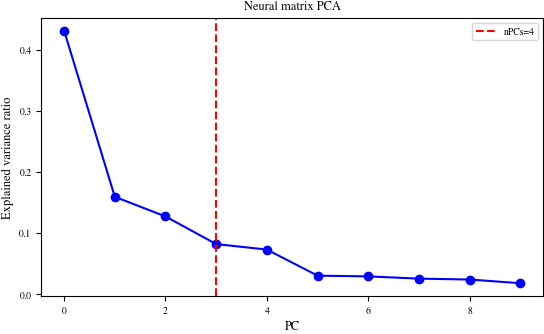

Neural matrix X shape: (1700, 4)


In [67]:
# ---- Build neural matrix X (mirrors cells 24) ---------------------------
sigT  = tensorX
permT, fitT = getPermutedTensor(factors, lambdas, sigT, NDIRS)
scld_permT  = permT

X_raw, _ = getNeuralMatrix(
    scld_permT, factors, lambdas, NDIRS,
    all_zeroed_stims=None, order='F', verbose=False)

# PCA — fit on all R components first to determine adaptive nPCs
pca_neural = PCA(len(lambdas))
pcaX       = pca_neural.fit_transform(X_raw)  # (N_all, R)

# Adaptive nPCs: smallest number of PCs that explain >= MIN_EXPL_VAR_RATIO variance
nPCs = np.flatnonzero(np.cumsum(pca_neural.explained_variance_ratio_) > MIN_EXPL_VAR_RATIO)[0] + 1
print(f'{nPCs=}  (explains >{MIN_EXPL_VAR_RATIO:.0%} cumulative variance)')

plt.plot(pca_neural.explained_variance_ratio_, 'bo-')
plt.axvline(nPCs - 1, color='red', linestyle='--', label=f'nPCs={nPCs}')
plt.xlabel('PC'); plt.ylabel('Explained variance ratio')
plt.legend(); plt.title('Neural matrix PCA'); plt.show()

X = pcaX[:, :nPCs]   # (N_all, nPCs)
print(f'Neural matrix X shape: {X.shape}')

In [68]:
# ---- Manual outlier removal (mirrors cells 26–27) -----------------------
# Adjust the slices below to match your encoding_manifolds.ipynb analysis.
D2_all = pwdists(X, sqdists=True)
N_all  = D2_all.shape[0]
D1_all = np.sqrt(D2_all)
mindists = np.min(D1_all + np.eye(N_all) * D1_all.max(), axis=0)

outls_far   = np.argsort(mindists)[::-1][:3]    # 3 most distant points
outls_close = np.argsort(mindists)[:10]          # 37 near-duplicate points

outliers_list = np.unique(np.append(outls_far, outls_close))
nonoutliers   = np.array([i for i in range(X.shape[0]) if i not in outliers_list])

# X_full: the PCA-reduced, outlier-filtered neural matrix — KEY INPUT
X_full = X[nonoutliers]   # shape (N_nonout, nPCs)
D2     = pwdists(X_full, sqdists=True)

print(f'X_full shape (N_nonout, nPCs): {X_full.shape}')
print(f'nonoutliers count: {len(nonoutliers)}')

X_full shape (N_nonout, nPCs): (1687, 4)
nonoutliers count: 1687


Running IAN (this may take several minutes)...


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:114: RuntimeWarning: divide by zero encountered in matmul
  return values[0] @ values[1]
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:114: RuntimeWarning: overflow encountered in matmul
  return values[0] @ values[1]
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/cvxpy/atoms/affine/binary_operators.py:114: RuntimeWarning: invalid value encountered in matmul
  return values[0] @ values[1]


### Iteration 1 done. (1.17 s) - pruned 9 edge(s)
### Iteration 2 done. (0.11 s) - pruned 9 edge(s)
### Iteration 3 done. (0.12 s) - pruned 8 edge(s)
### Iteration 4 done. (0.11 s) - pruned 9 edge(s)
### Iteration 5 done. (0.11 s) - pruned 8 edge(s)
### Iteration 6 done. (0.11 s) - pruned 8 edge(s)
### Iteration 7 done. (0.11 s) - pruned 8 edge(s)
### Iteration 8 done. (0.11 s) - pruned 8 edge(s)
### Iteration 9 done. (0.11 s) - pruned 8 edge(s)
### Iteration 10 done. (0.10 s) - pruned 8 edge(s)
### Iteration 11 done. (0.11 s) - pruned 8 edge(s)
### Iteration 12 done. (0.10 s) - pruned 8 edge(s)
### Iteration 13 done. (0.11 s) - pruned 8 edge(s)
### Iteration 14 done. (0.10 s) - pruned 8 edge(s)
### Iteration 15 done. (0.10 s) - pruned 8 edge(s)
### Iteration 16 done. (0.11 s) - pruned 8 edge(s)
### Iteration 17 done. (0.11 s) - pruned 7 edge(s)
### Iteration 18 done. (0.10 s) - pruned 7 edge(s)
### Iteration 19 done. (0.10 s) - pruned 7 edge(s)
### Iteration 20 done. (0.10 s) - pruned

/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/ian/ian.py:65: RuntimeWarning: overflow encountered in exp
  np.exp(-power, where=power < maxpow, out=K)#avoid underflow warnings


Unweighted graph stats: mean=1.208, median=0.946
Weighted graph stats: mean=1.021, median=0.939


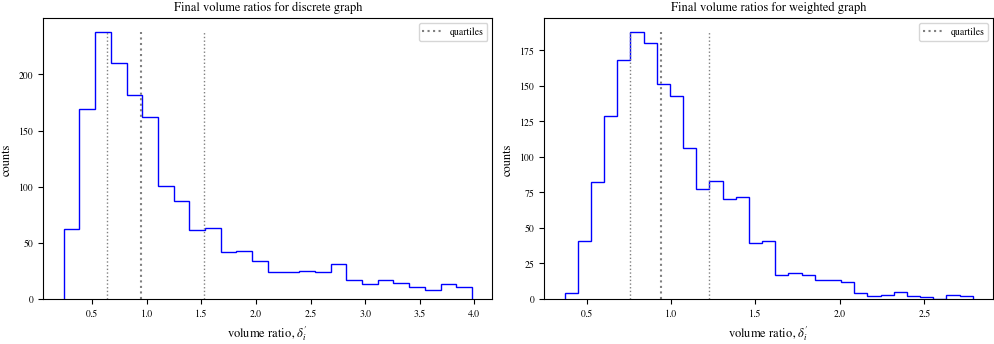

wG saved to ../data/wG/flyvis_T_Tm_i3_n1700_model000_10.npy
After IAN cleanup: 1686 nonoutliers
wG shape: (1686, 1686)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 427432 stored elements and shape (1686, 1686)>
  Coords	Values
  (0, 0)	1.0
  (0, 2)	0.0013954392761146807
  (0, 6)	0.26453393190771946
  (0, 7)	0.040595925737478694
  (0, 8)	0.1268321969280837
  (0, 10)	0.12664430432649432
  (0, 12)	0.1362691669338579
  (0, 14)	4.5978228560739116e-07
  (0, 20)	0.036220023309816524
  (0, 21)	0.01434792450774428
  (0, 22)	0.03519488078481975
  (0, 23)	0.004087828184432491
  (0, 24)	3.0557567964387597e-07
  (0, 28)	0.031583086114527564
  (0, 29)	2.8846788380489913e-06
  (0, 30)	0.004241592883127494
  (0, 36)	0.8901624395286742
  (0, 37)	0.348275553998118
  (0, 38)	0.0020479369062657207
  (0, 43)	0.013868015795347395
  (0, 44)	6.79908177873235e-08
  (0, 49)	0.09649721652519866
  (0, 160)	1.0667874725086723e-08
  (0, 184)	1.3604353805927165e-06
  (0, 197)	3.30921575242249e-07
  

In [69]:
# ---- IAN graph (mirrors cell 29) ----------------------------------------
# Load precomputed wG if available (fast path), otherwise recompute (slow).

wG_path = f'{basedir_wG}/{PREFIX}_{R}.npy'

if os.path.exists(wG_path):
    print('Loading precomputed wG from', wG_path)
    wG_dense = np.load(wG_path)
    wG = csr_matrix(wG_dense)
    # Reconstruct binary adjacency from saved wG
    G  = (wG_dense > 0).astype(float)
    optScales = np.ones(X_full.shape[0])  # placeholder (not needed downstream)
    disc_pts  = []
else:
    print('Running IAN (this may take several minutes)...')
    solver = None  # set to 'GUROBI' for faster convergence
    G, wG, optScales, disc_pts = IAN('exact-precomputed-sq', D2, solver=solver)
    np.save(wG_path, wG.toarray())
    print('wG saved to', wG_path)

    # Handle any disconnected points from IAN
    wG, G, outliers_list, nonoutliers, _ = handle_disconnected_points(
        disc_pts, optScales, G, D2, outliers_list, neurons_used, X)
    X_full = X[nonoutliers]
    print(f'After IAN cleanup: {len(nonoutliers)} nonoutliers')

print(f'wG shape: {wG.shape}')
print(wG)

In [70]:
# ---- Diffusion maps + MDS embedding (mirrors cells 34–36) ---------------
diffmap_y, diffmap_evals = diffusionMapSparseK(csr_matrix(wG), 20, 1, t=1)
embedding_ = compute_mds_embedding(diffmap_y, nPCs, n_components=10)

# Pre-filter tensor to nonoutlier space so all subpop indexing is direct.
# Must come AFTER the IAN cell since that cell may update nonoutliers from cache.
tensor4d_nonout = tensor4d[nonoutliers]   # (N_nonout, S, D, T)

print(f'diffmap_y shape:  {diffmap_y.shape}')        # (N_nonout, 19)
print(f'embedding_ shape: {embedding_.shape}')       # (N_nonout, 10)
print(f'tensor4d_nonout:  {tensor4d_nonout.shape}')  # (N_nonout, S, D, T)

diffmap_y shape:  (1686, 20)
embedding_ shape: (1686, 10)
tensor4d_nonout:  (1686, 6, 8, 37)


Number of clusters: 4
Cluster label range: -1 to 2


/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:568: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


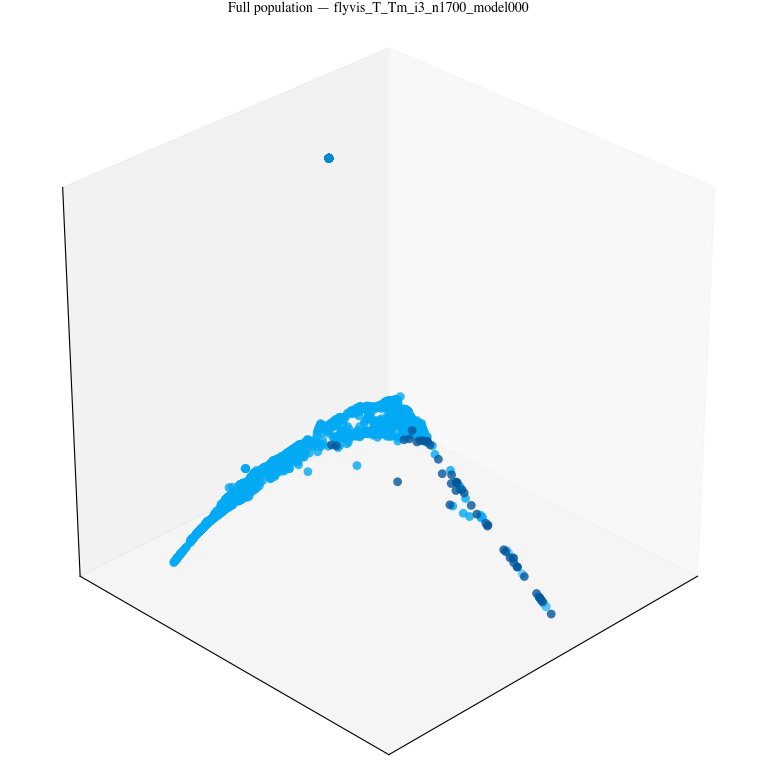

In [71]:
# ---- HDBSCAN clustering (for Method 2 cluster selection) ----------------
cluster_labels, num_clusters, cond_tree, leaves = run_hdbscan_clustering(
    diffmap_y, nPCs, G, min_cluster_size=10)

print(f'Number of clusters: {num_clusters}')
print(f'Cluster label range: {cluster_labels.min()} to {cluster_labels.max()}')

# Quick 3D embedding overview colored by cluster
fig_overview, ax_overview = plot_encoding_manifold_3d(
    embedding_, cluster_labels, PALETTE, dcs=(0, 1, 2),
    title=f'Full population — {PREFIX}')
plt.show()

## Section 2: Choose Subpopulation <a id='section-2'></a>

Run **one** of the subsections below (Method 1, 2a, 2b, or 2c), then run the
validation cell at the end of this section.

### Method 1 — Dynamic Filtering

/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:70: RuntimeWarning: divide by zero encountered in matmul
  linear_fit = X_time @ slopes_intercepts                           # (T_early, N*S)
/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:70: RuntimeWarning: overflow encountered in matmul
  linear_fit = X_time @ slopes_intercepts                           # (T_early, N*S)
/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:70: RuntimeWarning: invalid value encountered in matmul
  linear_fit = X_time @ slopes_intercepts                           # (T_early, N*S)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/

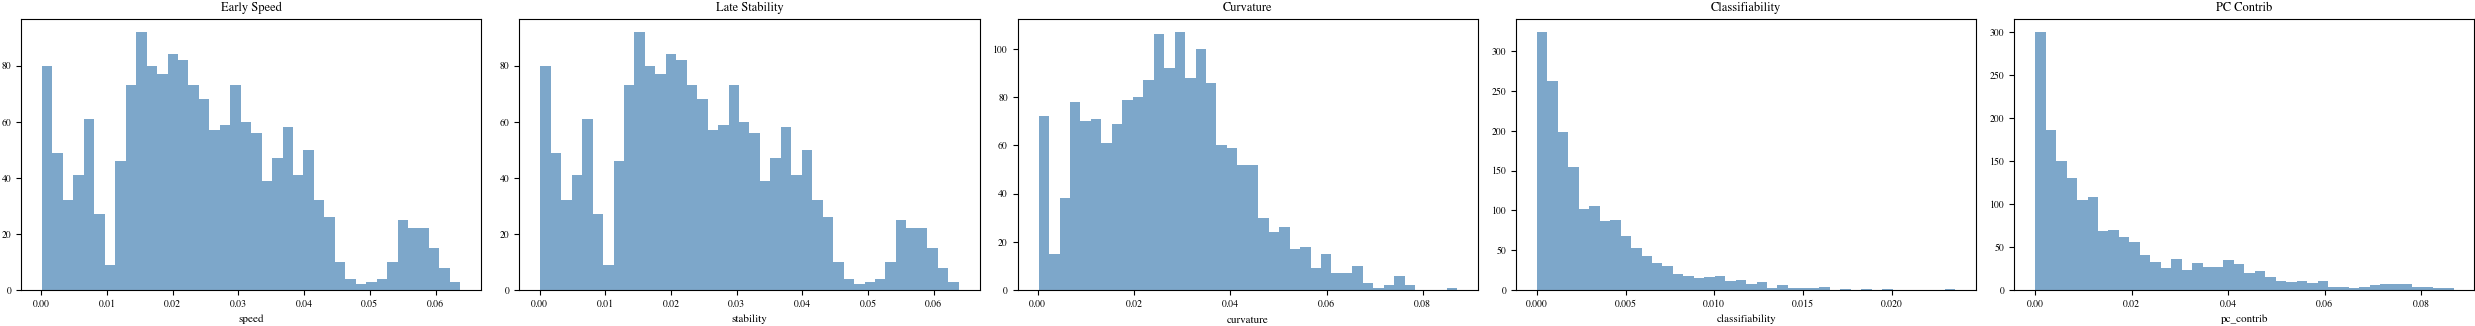

speed               : min=0.0001  max=0.0638  mean=0.0243
stability           : min=0.0001  max=0.0638  mean=0.0243
curvature           : min=0.0002  max=0.0871  mean=0.0273
classifiability     : min=0.0000  max=0.0236  mean=0.0031
pc_contrib          : min=0.0000  max=0.0867  mean=0.0167


In [72]:
# Compute per-neuron dynamic metrics over the full population (all N neurons).
# We remap to nonoutlier space in the filter cell below.
metrics = compute_dynamic_metrics(tensor4d, target_stim_idx=None)

# Inspect distributions (no selection yet)
fig_metrics, _ = plot_metric_distributions(metrics)
plt.show()

for k, v in metrics.items():
    print(f'{k:20s}: min={v.min():.4f}  max={v.max():.4f}  mean={v.mean():.4f}')

Selected 85 / 1700 neurons (full space)
After nonoutlier restriction: 74 neurons


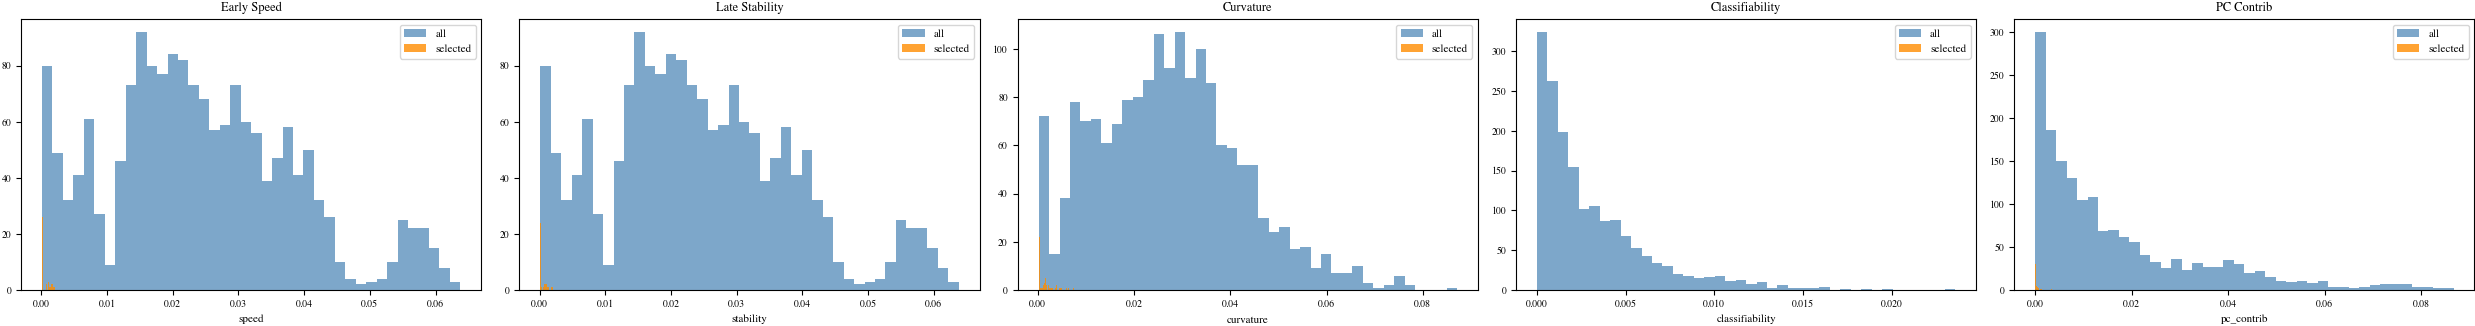

In [73]:
# --- Config ---
METRIC     = 'speed'   # 'speed' | 'stability' | 'curvature' | 'classifiability' | 'pc_contrib'
PERCENTILE = 5       # percent of neurons to select (e.g. 2 → top or bottom 2%)
SIDE       = 'low'     # 'high' → top PERCENTILE%,  'low' → bottom PERCENTILE%

# --- Apply filter ---
if SIDE == 'high':
    selected_mask = filter_neurons_by_metric(metrics, METRIC, percentile_gt=100 - PERCENTILE)
else:
    selected_mask = filter_neurons_by_metric(metrics, METRIC, percentile_lt=PERCENTILE)

# Example compound filter (uncomment to use):
# selected_mask = (
#     filter_neurons_by_metric(metrics, 'speed', percentile_gt=99.75) &
#     filter_neurons_by_metric(metrics, 'stability', percentile_lt=50)
# )

# selected_mask is in full-population space (N neurons).
# Restrict to the nonoutlier set so subpop_indices align with tensor4d_nonout.
subpop_mask    = selected_mask[nonoutliers]   # nonoutlier-space bool, length N_nonout
subpop_indices = np.where(subpop_mask)[0]     # indices into tensor4d_nonout rows

print(f'Selected {selected_mask.sum()} / {len(selected_mask)} neurons (full space)')
print(f'After nonoutlier restriction: {subpop_mask.sum()} neurons')

# Overlay selected neurons on metric distributions (full-space mask for correct histograms)
fig_metrics2, _ = plot_metric_distributions(metrics, selected_mask)
plt.show()

### Method 2a — Cluster Selection

In [74]:
"""# Inspect cluster plot above, then set target cluster(s)
target_cluster = 0   # change after inspecting the overview plot

subpop_mask    = select_neurons_by_cluster(cluster_labels, target_cluster)
subpop_indices = np.where(subpop_mask)[0]

print(f'Cluster {target_cluster}: {subpop_mask.sum()} neurons selected')"""

"# Inspect cluster plot above, then set target cluster(s)\ntarget_cluster = 0   # change after inspecting the overview plot\n\nsubpop_mask    = select_neurons_by_cluster(cluster_labels, target_cluster)\nsubpop_indices = np.where(subpop_mask)[0]\n\nprint(f'Cluster {target_cluster}: {subpop_mask.sum()} neurons selected')"

### Method 2b — Bounding Box

In [75]:
"""# Define bounding box in embedding space (dim index → (min, max))
bounds = {0: (-0.2, 0.2), 1: (0.1, 0.4)}
#bounds = {0: (0.2, 5), }

subpop_mask    = select_neurons_by_bbox(embedding_, bounds)
subpop_indices = np.where(subpop_mask)[0]

print(f'Bounding box selection: {subpop_mask.sum()} neurons')"""

"# Define bounding box in embedding space (dim index → (min, max))\nbounds = {0: (-0.2, 0.2), 1: (0.1, 0.4)}\n#bounds = {0: (0.2, 5), }\n\nsubpop_mask    = select_neurons_by_bbox(embedding_, bounds)\nsubpop_indices = np.where(subpop_mask)[0]\n\nprint(f'Bounding box selection: {subpop_mask.sum()} neurons')"

### Method 2c — Seed + Radius

In [76]:
"""seed_idx = 42    # index in nonoutlier space
radius   = 0.03

subpop_mask    = select_neurons_by_radius(embedding_, seed_idx, radius)
subpop_indices = np.where(subpop_mask)[0]

print(f'Radius selection (seed={seed_idx}, r={radius}): {subpop_mask.sum()} neurons')"""

"seed_idx = 42    # index in nonoutlier space\nradius   = 0.03\n\nsubpop_mask    = select_neurons_by_radius(embedding_, seed_idx, radius)\nsubpop_indices = np.where(subpop_mask)[0]\n\nprint(f'Radius selection (seed={seed_idx}, r={radius}): {subpop_mask.sum()} neurons')"

### Validation — Where does the subpopulation sit?

/Users/johannesbertram/repos/FNN_Manifolds/plotting/subpop_utils.py:437: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


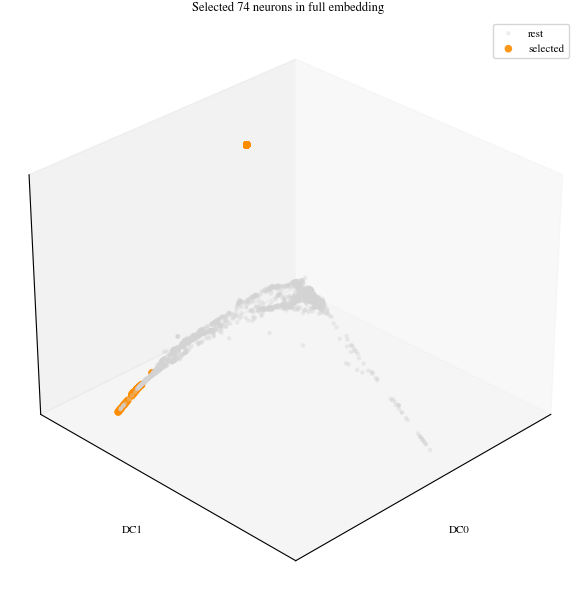

Subpopulation size in nonoutlier space: 74


In [77]:
# 3D scatter: rest in gray, selected highlighted
fig_loc, ax_loc = plot_neuron_locations_in_manifold(
    embedding_, subpop_mask, dcs=(0, 1, 2))
ax_loc.set_title(f'Selected {subpop_mask.sum()} neurons in full embedding')
plt.show()

print(f'Subpopulation size in nonoutlier space: {len(subpop_indices)}')

## Section 3: Decoding Analysis <a id='section-3'></a>

In [78]:
# subpop_indices are in nonoutlier space (0..N_nonout-1).
# tensor4d_nonout is already filtered to nonoutlier space, so index directly.
print(subpop_indices)
tensor4d_sub = tensor4d_nonout[subpop_indices]   # (K, S, D, T)

print(f'tensor4d_sub shape: {tensor4d_sub.shape}')

[1049 1050 1051 1052 1053 1054 1055 1056 1057 1058 1059 1060 1061 1062
 1063 1064 1065 1066 1067 1068 1069 1070 1071 1072 1073 1074 1075 1076
 1077 1078 1079 1080 1081 1082 1083 1084 1085 1086 1087 1088 1439 1440
 1443 1445 1448 1449 1452 1455 1458 1459 1468 1472 1474 1475 1480 1481
 1482 1484 1486 1488 1510 1514 1515 1523 1586 1608 1623 1631 1642 1648
 1656 1657 1663 1666]
tensor4d_sub shape: (74, 6, 8, 37)


In [79]:
# ---- Decoding manifolds: full population vs subpop (side by side) -------
coords_full, _ = compute_decoding_manifold(tensor4d_nonout, n_components=3)
coords_sub,  _ = compute_decoding_manifold(tensor4d_sub,    n_components=3)

lbls = np.array([lb for lb in LABELS for _ in range(N_DIR)])

/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_97922/3760879627.py:17: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


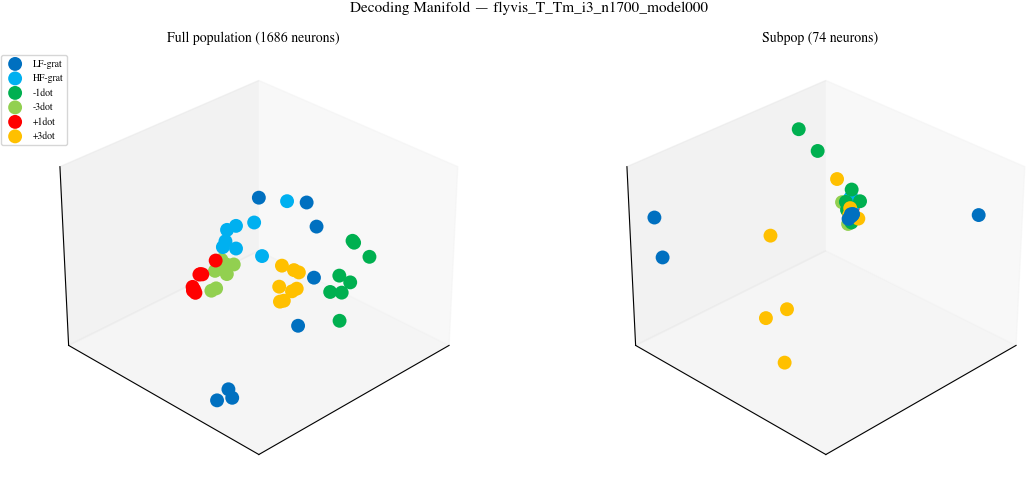

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})
for ax, coords, title in [
        (axes[0], coords_full, f'Full population ({len(nonoutliers)} neurons)'),
        (axes[1], coords_sub,  f'Subpop ({len(subpop_indices)} neurons)')]:
    for i, label in enumerate(LABELS):
        mask = lbls == label
        ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
                   color=STIMULUS_COLORS[i], s=100, edgecolors='none',
                   depthshade=False, label=label)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False)
    ax.view_init(elev=30, azim=45)
    ax.set_title(title, fontsize=10)

axes[0].legend(fontsize=7, loc='upper left', bbox_to_anchor=(-0.1, 1.0))
fig.suptitle(f'Decoding Manifold — {PREFIX}', fontsize=11)
fig.tight_layout()
plt.savefig(f'{basedir_fig}/decoding_manifolds/{PREFIX}_subpop_comparison.pdf',
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [81]:
# ---- Decoding trajectories: full population vs subpop (side by side) ----
trajs_full, _ = compute_decoding_trajectories(tensor4d_nonout, n_components=3)
trajs_sub,  _ = compute_decoding_trajectories(tensor4d_sub,    n_components=3)

def _plot_trajs_on_ax(ax, trajs, title):
    for i, traj in enumerate(trajs):
        color = STIMULUS_COLORS[(i // N_DIR) % len(STIMULUS_COLORS)]
        x, y, z = traj[:, 0], traj[:, 1], traj[:, 2] * 0.5
        ax.plot(x, y, z, color=color, linewidth=1.5, alpha=0.35)
        ax.scatter(x[0],  y[0],  z[0],  color='black', s=15, depthshade=False, edgecolors='none')
        ax.scatter(x[-1], y[-1], z[-1], color=color,   s=60, depthshade=False, edgecolors='none')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False)
    ax.view_init(elev=30, azim=45)
    ax.set_title(title, fontsize=10)

/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_97922/2012585862.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


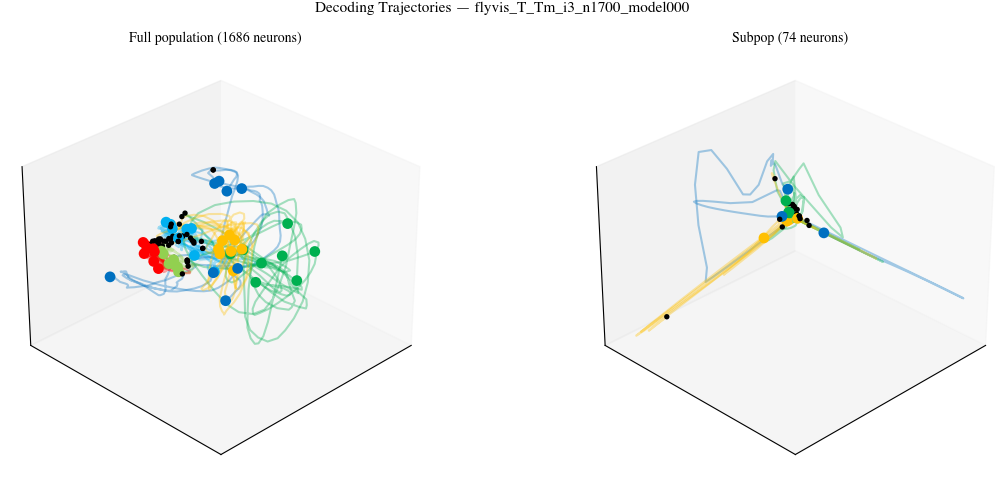

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})
_plot_trajs_on_ax(axes[0], trajs_full, f'Full population ({len(nonoutliers)} neurons)')
_plot_trajs_on_ax(axes[1], trajs_sub,  f'Subpop ({len(subpop_indices)} neurons)')
fig.suptitle(f'Decoding Trajectories — {PREFIX}', fontsize=11)
fig.tight_layout()
plt.savefig(f'{basedir_fig}/decoding_trajectories/crossings_{PREFIX}_subpop_comparison.pdf',
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

## Section 4: Encoding Analysis <a id='section-4'></a>

Rebuilds IAN + diffusion maps + MDS on just the subpopulation, then shows
the full population encoding manifold (subpop highlighted) alongside the
rebuilt subpop-only manifold.

### Full rebuild — fresh manifold from subpopulation only (minutes)

This re-runs IAN + diffusion maps + MDS on just the subpopulation.
Best for subpopulations of ≥ ~50 neurons.

Running IAN on 74 neurons...
### Iteration 1 done. (0.01 s) - pruned 1 edge(s)
### Iteration 2 done. (0.02 s) - pruned 1 edge(s)
### Iteration 3 done. (0.00 s) - pruned 1 edge(s)
### Iteration 4 done. (0.00 s) - pruned 1 edge(s)
### Iteration 5 done. (0.00 s) - pruned 1 edge(s)
### Iteration 6 done. (0.00 s) - pruned 1 edge(s)
CONVERGED: no change in unweighted graph.
Total # edges pruned: 6, (0 disconnected points)
C-tuning weighted graph...
Unweighted graph stats: mean=1.278, median=1.082
Weighted graph stats: mean=1.094, median=1.024


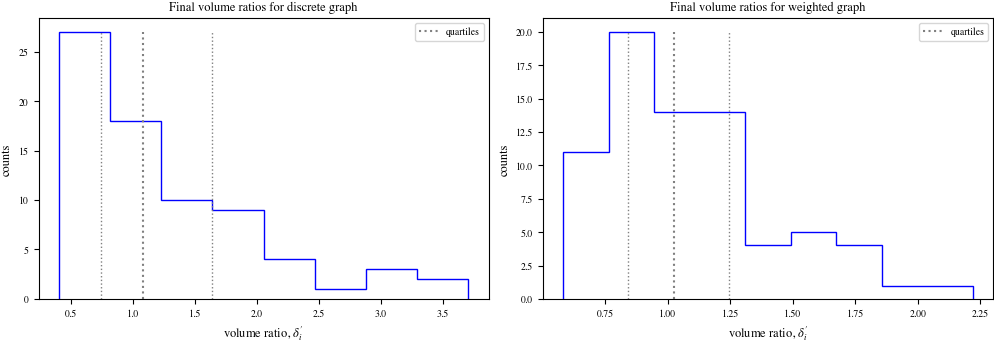

X_sub shape:      (74, 4)
nonoutliers:      74 clean neurons
embedding_ shape: (74, 10)


In [83]:
print(f'Running IAN on {len(subpop_indices)} neurons...')

enc = build_encoding_manifold_for_subpop(
    X_full, subpop_indices, nPCs=nPCs,
    solver=None,              # set 'GUROBI' for faster convergence
    n_diffmap_components=20,
    n_mds_components=10
)

print(f"X_sub shape:      {enc['X_sub'].shape}")
print(f"nonoutliers:      {len(enc['nonoutliers'])} clean neurons")
print(f"embedding_ shape: {enc['embedding_'].shape}")

Subpop clusters: 6


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_97922/2433698709.py:32: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


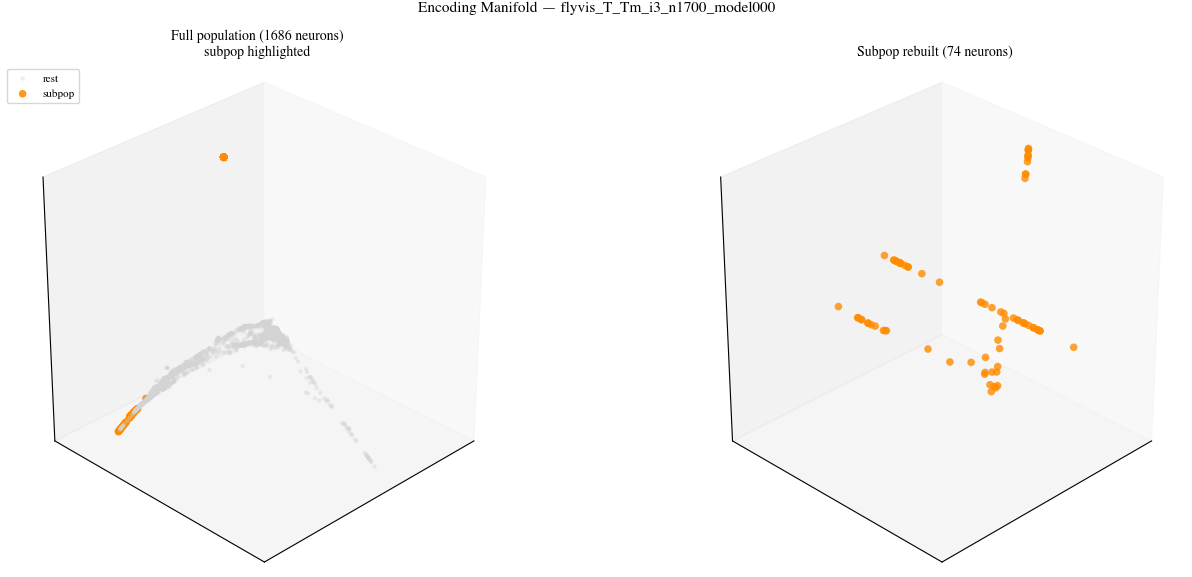

In [84]:
# Cluster the rebuilt subpop encoding manifold
sub_labels, sub_n_clusters, _, _ = run_hdbscan_clustering(
    enc['diffmap_y'], nPCs, enc['G'], min_cluster_size=5)

print(f'Subpop clusters: {sub_n_clusters}')

# ---- Encoding manifolds: full pop (subpop highlighted) vs rebuilt subpop --
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

# Left: full population, subpop colored in orange
ax = axes[0]
ax.scatter(embedding_[~subpop_mask, 0], embedding_[~subpop_mask, 1], embedding_[~subpop_mask, 2],
           c='lightgray', s=10, alpha=0.4, edgecolors='none', depthshade=False, label='rest')
ax.scatter(embedding_[subpop_mask, 0], embedding_[subpop_mask, 1], embedding_[subpop_mask, 2],
           c='darkorange', s=30, alpha=0.9, edgecolors='none', depthshade=False, label='subpop')
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.grid(False); ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=30, azim=45)
ax.set_title(f'Full population ({len(nonoutliers)} neurons)\nsubpop highlighted', fontsize=10)
ax.legend(fontsize=8, loc='upper left')

# Right: rebuilt subpop-only manifold, single color
ax = axes[1]
ax.scatter(enc['embedding_'][:, 0], enc['embedding_'][:, 1], enc['embedding_'][:, 2],
           c='darkorange', s=30, alpha=0.8, edgecolors='none', depthshade=False)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.grid(False); ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=30, azim=45)
ax.set_title(f'Subpop rebuilt ({len(enc["nonoutliers"])} neurons)', fontsize=10)

fig.suptitle(f'Encoding Manifold — {PREFIX}', fontsize=11)
fig.tight_layout()
plt.savefig(f'{basedir_fig}/3d_manifolds/{PREFIX}_subpop_encoding_comparison.pdf',
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()

## Section 5: PSTH Heatmaps <a id='section-5'></a>

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_97922/31431889.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


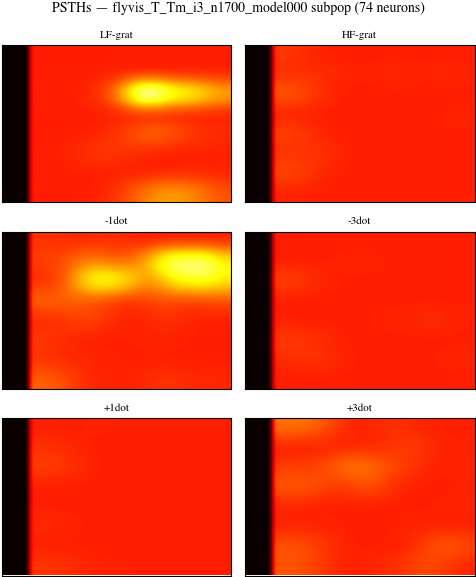

In [85]:
# ---- PSTH heatmap sixtuplet averaged over subpopulation -----------------
# tensorX is full-population space; map subpop from nonoutlier → full space.
plot_permT = np.reshape(tensorX, (len(tensorX), N_STIM, -1, N_DIR))
neuron_idx_full = nonoutliers[subpop_indices]   # indices into full population

# Pre-compute all panels and find global color range
panels = []
for stim in range(N_STIM):
    pst_orig = np.mean(plot_permT[neuron_idx_full, stim, :, :], axis=0).T  # (N_DIR, T)
    pst = np.zeros((pst_orig.shape[0], pst_orig.shape[1] + 5))
    pst[:, 5:] = pst_orig
    opt_dir = pst.mean(1).argmax()
    pst = np.roll(pst, (2 - opt_dir) % N_DIR, 0)
    panels.append(pst)

vmin = min(p.min() for p in panels)
vmax = max(p.max() for p in panels)

fig, axs = plt.subplots(3, 2, figsize=(5, 6))
for stim, pst in enumerate(panels):
    axs[stim // 2, stim % 2].imshow(pst, aspect='auto', interpolation='quadric',
                                     cmap='hot', vmin=vmin, vmax=vmax)
    axs[stim // 2, stim % 2].xaxis.set_visible(False)
    axs[stim // 2, stim % 2].yaxis.set_visible(False)
    axs[stim // 2, stim % 2].set_title(LABELS[stim], fontsize=8)

fig.suptitle(f'PSTHs — {PREFIX} subpop ({len(subpop_indices)} neurons)', fontsize=10)
plt.tight_layout()
plt.savefig(f'{basedir_fig}/{PREFIX}_subpop_psth.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()